# Exploración inicial del dataset – Smart Warehouse GridWorld

**Proyecto:** Comparación de SARSA, Q-Learning y Monte Carlo en un gemelo digital simplificado de un almacén inteligente.



## 1. Carga de librerías y dataset

Se ejecuta el notebook desde la misma carpeta donde se encuentran los archivos `smart_warehouse_cells.csv`, `smart_warehouse_transitions.csv` y `smart_warehouse_maps.json`.

In [35]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

cells_path = Path('smart_warehouse_cells.csv')
trans_path = Path('smart_warehouse_transitions.csv')
maps_path = Path('smart_warehouse_maps.json')

cells_df = pd.read_csv(cells_path)
trans_df = pd.read_csv(trans_path)

with open(maps_path, 'r', encoding='utf-8') as f:
    maps_data = json.load(f)

maps = maps_data['mapas']

print('smart_warehouse_cells.csv       →', cells_df.shape)
print('smart_warehouse_transitions.csv →', trans_df.shape)
print('Almacenes disponibles:', list(maps.keys()))

smart_warehouse_cells.csv       → (189, 13)
smart_warehouse_transitions.csv → (528, 13)
Almacenes disponibles: ['almacen_5x5_baja', 'almacen_8x8_media', 'almacen_10x10_alta']


## 2. Vista inicial de los archivos

In [36]:
display(cells_df.head())
display(trans_df.head())

,almacen_id,filas_almacen,columnas_almacen,estado_id,fila,columna,simbolo_celda,tipo_zona,descripcion_zona,recompensa_entrada,es_terminal,es_obstaculo,max_pasos_episodio
0,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,Posición inicial del robot autónomo dentro del...,-1.0,False,False,50
1,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50
2,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c2,0,2,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50
3,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c3,0,3,X,estanteria,Estantería o zona bloqueada no transitable.,NaN,False,True,50
4,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c4,0,4,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50


,almacen_id,estado_id,fila,columna,accion,siguiente_estado_id,siguiente_fila,siguiente_columna,siguiente_simbolo_celda,siguiente_tipo_zona,recompensa,terminado,evento
0,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,arriba,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,-5,False,fuera_del_almacen
1,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,abajo,almacen_5x5_baja_r1_c0,1,0,.,pasillo_libre,-1,False,movimiento_por_pasillo
2,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,izquierda,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,-5,False,fuera_del_almacen
3,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,derecha,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,-1,False,movimiento_por_pasillo
4,almacen_5x5_baja,almacen_5x5_baja_r0_c1,0,1,arriba,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,-5,False,fuera_del_almacen


## 3. Información general del dataset

Se revisan tipos de variables, cantidad de registros y estructura general de cada archivo.

In [37]:
print('=== CELDAS DEL ALMACÉN ===')
cells_df.info()

print()
print('=== TRANSICIONES ESTADO-ACCIÓN ===')
trans_df.info()

=== CELDAS DEL ALMACÉN ===
<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   almacen_id          189 non-null    str    
 1   filas_almacen       189 non-null    int64  
 2   columnas_almacen    189 non-null    int64  
 3   estado_id           189 non-null    str    
 4   fila                189 non-null    int64  
 5   columna             189 non-null    int64  
 6   simbolo_celda       189 non-null    str    
 7   tipo_zona           189 non-null    str    
 8   descripcion_zona    189 non-null    str    
 9   recompensa_entrada  132 non-null    float64
 10  es_terminal         189 non-null    bool   
 11  es_obstaculo        189 non-null    bool   
 12  max_pasos_episodio  189 non-null    int64  
dtypes: bool(2), float64(1), int64(5), str(5)
memory usage: 32.9 KB

=== TRANSICIONES ESTADO-ACCIÓN ===
<class 'pandas.DataFrame'>
RangeIndex: 5

## 4. Valores faltantes

En este dataset, las estanterías no son estados visitables. Por eso, la recompensa de entrada puede aparecer vacía en dichas celdas.

In [38]:
print('Valores faltantes en celdas:')
display(cells_df.isnull().sum())

print('Valores faltantes en transiciones:')
display(trans_df.isnull().sum())

Valores faltantes en celdas:


almacen_id             0
filas_almacen          0
columnas_almacen       0
estado_id              0
fila                   0
columna                0
simbolo_celda          0
tipo_zona              0
descripcion_zona       0
recompensa_entrada    57
es_terminal            0
es_obstaculo           0
max_pasos_episodio     0
dtype: int64

Valores faltantes en transiciones:


almacen_id                 0
estado_id                  0
fila                       0
columna                    0
accion                     0
siguiente_estado_id        0
siguiente_fila             0
siguiente_columna          0
siguiente_simbolo_celda    0
siguiente_tipo_zona        0
recompensa                 0
terminado                  0
evento                     0
dtype: int64

## 5. Distribución de zonas del almacén

Se analiza cuántas celdas corresponden a pasillos, estanterías, zonas congestionadas, inicio del robot y zona de entrega.

tipo_zona
pasillo_libre         119
estanteria             57
zona_congestionada      7
inicio_robot            3
zona_entrega            3
Name: count, dtype: int64

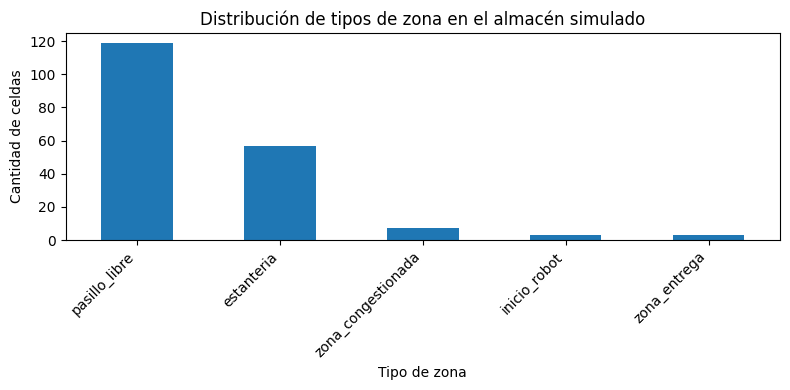

In [39]:
dist_zonas = cells_df['tipo_zona'].value_counts()
display(dist_zonas)

ax = dist_zonas.plot(kind='bar', figsize=(8, 4))
ax.set_title('Distribución de tipos de zona en el almacén simulado')
ax.set_xlabel('Tipo de zona')
ax.set_ylabel('Cantidad de celdas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Distribución por mapa

El dataset contiene tres almacenes simulados con distinta complejidad: baja, media y alta.

tipo_zona,estanteria,inicio_robot,pasillo_libre,zona_congestionada,zona_entrega
almacen_id,,,,,
almacen_10x10_alta,33,1,62,3,1
almacen_5x5_baja,6,1,16,1,1
almacen_8x8_media,18,1,41,3,1


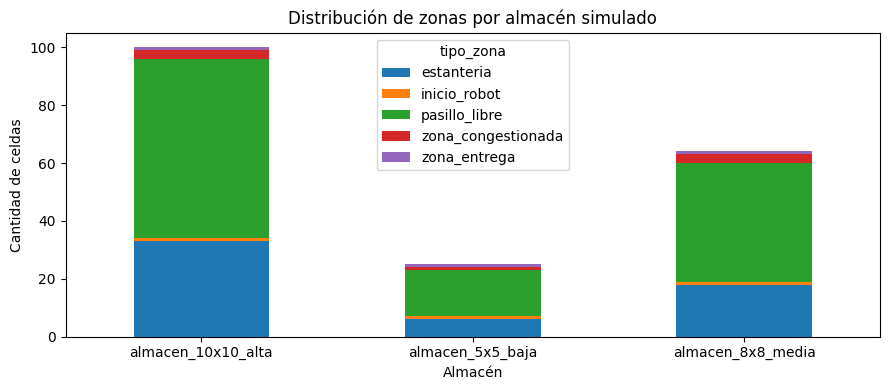

In [40]:
resumen_por_mapa = pd.crosstab(cells_df['almacen_id'], cells_df['tipo_zona'])
display(resumen_por_mapa)

ax = resumen_por_mapa.plot(kind='bar', stacked=True, figsize=(9, 4))
ax.set_title('Distribución de zonas por almacén simulado')
ax.set_xlabel('Almacén')
ax.set_ylabel('Cantidad de celdas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Eventos disponibles en las transiciones

Cada transición indica qué ocurre cuando el robot ejecuta una acción desde una celda determinada.

evento
movimiento_por_pasillo      260
choque_con_estanteria       151
fuera_del_almacen            75
entra_zona_congestionada     18
estado_terminal              12
vuelve_inicio_robot           6
llega_zona_entrega            6
Name: count, dtype: int64

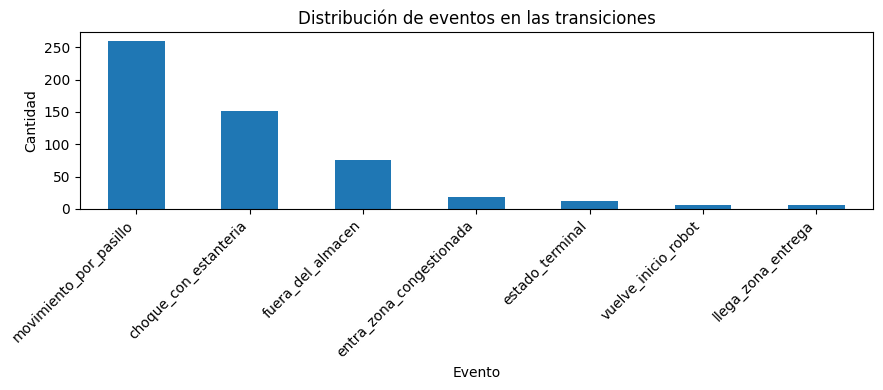

In [41]:
eventos = trans_df['evento'].value_counts()
display(eventos)

ax = eventos.plot(kind='bar', figsize=(9, 4))
ax.set_title('Distribución de eventos en las transiciones')
ax.set_xlabel('Evento')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Visualización de los almacenes simulados

La siguiente función permite visualizar los mapas como grillas. La interpretación es:

- `S`: inicio del robot.
- `G`: zona de entrega.
- `X`: estantería u obstáculo.
- `R`: zona congestionada.
- `.`: pasillo libre.

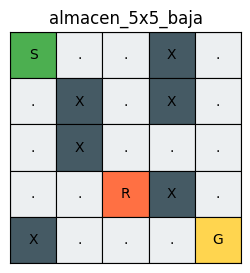

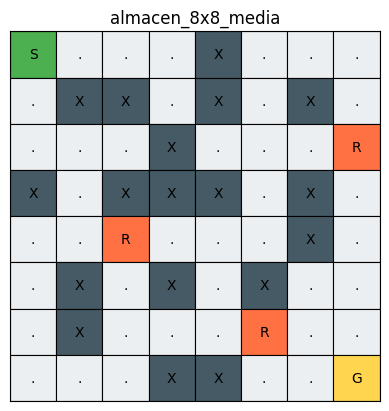

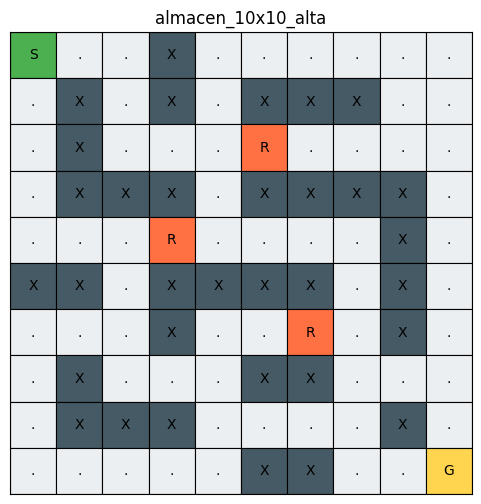

In [42]:
def visualizar_almacen(nombre_mapa, mapa):
    colores = {
        'S': '#4CAF50',  # inicio robot
        'G': '#FFD54F',  # zona entrega
        'X': '#455A64',  # estantería
        'R': '#FF7043',  # zona congestionada
        '.': '#ECEFF1'   # pasillo libre
    }
    etiquetas = {
        'S': 'Inicio robot',
        'G': 'Entrega',
        'X': 'Estantería',
        'R': 'Congestión',
        '.': 'Pasillo'
    }

    filas = len(mapa)
    columnas = len(mapa[0])
    fig, ax = plt.subplots(figsize=(columnas * 0.6, filas * 0.6))

    for i, fila in enumerate(mapa):
        for j, simbolo in enumerate(fila):
            rect = plt.Rectangle((j, filas - i - 1), 1, 1,
                                 facecolor=colores.get(simbolo, 'white'),
                                 edgecolor='black', linewidth=0.8)
            ax.add_patch(rect)
            ax.text(j + 0.5, filas - i - 0.5, simbolo,
                    ha='center', va='center', fontsize=10)

    ax.set_xlim(0, columnas)
    ax.set_ylim(0, filas)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(nombre_mapa)
    plt.show()

for nombre, mapa in maps.items():
    visualizar_almacen(nombre, mapa)

## 9. Resumen 

In [43]:
print('Resumen del dataset actualizado')
print('Cantidad de almacenes simulados:', cells_df['almacen_id'].nunique())
print('Total de celdas:', len(cells_df))
print('Total de transiciones:', len(trans_df))
print('Tipos de zona:', ', '.join(cells_df['tipo_zona'].unique()))
print('Acciones disponibles:', ', '.join(trans_df['accion'].unique()))
print()
print('Distribución global:')
print(cells_df['tipo_zona'].value_counts())

Resumen del dataset actualizado
Cantidad de almacenes simulados: 3
Total de celdas: 189
Total de transiciones: 528
Tipos de zona: inicio_robot, pasillo_libre, estanteria, zona_congestionada, zona_entrega
Acciones disponibles: arriba, abajo, izquierda, derecha

Distribución global:
tipo_zona
pasillo_libre         119
estanteria             57
zona_congestionada      7
inicio_robot            3
zona_entrega            3
Name: count, dtype: int64


## 10. Preparación del entorno para Q-Learning

Desde esta parte se agrega el primer experimento del Avance 2. Se usa el almacén de baja dificultad para comprobar que el agente pueda aprender una ruta funcional antes de probar escenarios más grandes.


In [44]:
# Selección del escenario inicial para el modelo base
almacen_id = 'almacen_5x5_baja'

cells_map = cells_df[cells_df['almacen_id'] == almacen_id].copy()
trans_map = trans_df[trans_df['almacen_id'] == almacen_id].copy()

acciones = ['arriba', 'abajo', 'izquierda', 'derecha']
estados_validos = sorted(cells_map[~cells_map['es_obstaculo']]['estado_id'].tolist())
estado_inicial = cells_map.loc[cells_map['simbolo_celda'] == 'S', 'estado_id'].iloc[0]
estado_meta = cells_map.loc[cells_map['simbolo_celda'] == 'G', 'estado_id'].iloc[0]
max_pasos = int(cells_map['max_pasos_episodio'].max())

transiciones = {
    (fila.estado_id, fila.accion): (
        fila.siguiente_estado_id,
        float(fila.recompensa),
        bool(fila.terminado),
        fila.evento
    )
    for fila in trans_map.itertuples(index=False)
}

print('Escenario utilizado:', almacen_id)
print('Estados válidos:', len(estados_validos))
print('Acciones disponibles:', acciones)
print('Estado inicial:', estado_inicial)
print('Estado meta:', estado_meta)
print('Máximo de pasos por episodio:', max_pasos)


Escenario utilizado: almacen_5x5_baja
Estados válidos: 19
Acciones disponibles: ['arriba', 'abajo', 'izquierda', 'derecha']
Estado inicial: almacen_5x5_baja_r0_c0
Estado meta: almacen_5x5_baja_r4_c4
Máximo de pasos por episodio: 50


## 11. Modelo base: Q-Learning

Se implementa Q-Learning como primer modelo base. La idea es partir con una referencia simple y funcional para luego comparar con SARSA y Monte Carlo.


In [45]:
import numpy as np
import random

# Parámetros iniciales
episodios = 500
alpha = 0.1      # tasa de aprendizaje
gamma = 0.9      # importancia de recompensas futuras
epsilon = 0.2    # probabilidad de explorar
semilla = 42

random.seed(semilla)
np.random.seed(semilla)

# Tabla Q inicial: un valor por cada combinación estado-acción
Q = {
    (estado, accion): 0.0
    for estado in estados_validos
    for accion in acciones
}

def elegir_accion(estado, epsilon_actual):
    # Exploración: probar una acción al azar
    if random.random() < epsilon_actual:
        return random.choice(acciones)

    # Explotación: usar la mejor acción conocida
    valores = [Q[(estado, accion)] for accion in acciones]
    valor_maximo = max(valores)
    mejores_acciones = [accion for accion, valor in zip(acciones, valores) if valor == valor_maximo]
    return random.choice(mejores_acciones)

historial = []

for episodio in range(1, episodios + 1):
    estado = estado_inicial
    recompensa_total = 0
    pasos = 0
    exito = False

    for _ in range(max_pasos):
        accion = elegir_accion(estado, epsilon)
        siguiente_estado, recompensa, terminado, evento = transiciones[(estado, accion)]

        recompensa_total += recompensa
        pasos += 1

        max_q_siguiente = max(Q[(siguiente_estado, a)] for a in acciones)
        Q[(estado, accion)] = Q[(estado, accion)] + alpha * (
            recompensa + gamma * max_q_siguiente - Q[(estado, accion)]
        )

        estado = siguiente_estado

        if terminado:
            exito = True
            break

    historial.append({
        'episodio': episodio,
        'recompensa_acumulada': recompensa_total,
        'pasos': pasos,
        'exito': exito
    })

resultados_qlearning = pd.DataFrame(historial)
display(resultados_qlearning.head())
display(resultados_qlearning.tail())


,episodio,recompensa_acumulada,pasos,exito
0,1,-144.0,50,False
1,2,45.0,32,True
2,3,67.0,13,True
3,4,-82.0,50,False
4,5,-90.0,50,False


,episodio,recompensa_acumulada,pasos,exito
495,496,84.0,8,True
496,497,63.0,12,True
497,498,93.0,8,True
498,499,84.0,13,True
499,500,93.0,8,True


## 12. Resultados iniciales

Se resumen las primeras métricas del entrenamiento: recompensa acumulada, cantidad de pasos y tasa de éxito. Estos valores servirán como comparación para los otros algoritmos.


In [46]:
resumen_resultados = pd.DataFrame({
    'Métrica': [
        'Recompensa promedio total',
        'Recompensa promedio últimos 100 episodios',
        'Pasos promedio total',
        'Pasos promedio últimos 100 episodios',
        'Tasa de éxito total',
        'Tasa de éxito últimos 100 episodios'
    ],
    'Valor': [
        resultados_qlearning['recompensa_acumulada'].mean(),
        resultados_qlearning.tail(100)['recompensa_acumulada'].mean(),
        resultados_qlearning['pasos'].mean(),
        resultados_qlearning.tail(100)['pasos'].mean(),
        resultados_qlearning['exito'].mean(),
        resultados_qlearning.tail(100)['exito'].mean()
    ]
})

display(resumen_resultados)


,Métrica,Valor
0,Recompensa promedio total,84.680
1,Recompensa promedio últimos 100 episodios,85.180
2,Pasos promedio total,10.770
3,Pasos promedio últimos 100 episodios,10.260
4,Tasa de éxito total,0.994
5,Tasa de éxito últimos 100 episodios,1.000


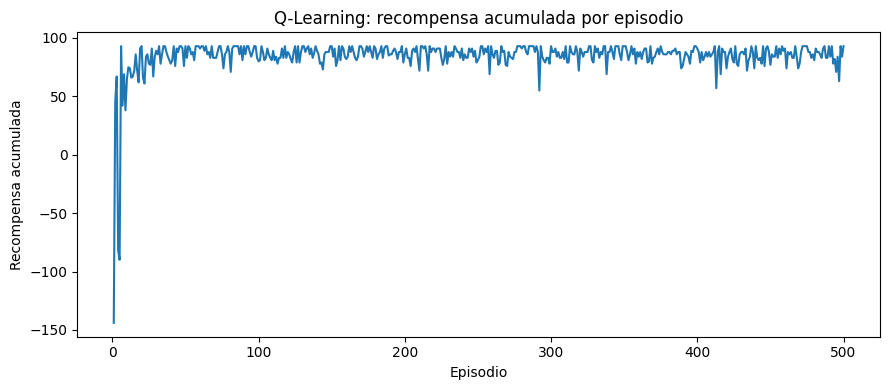

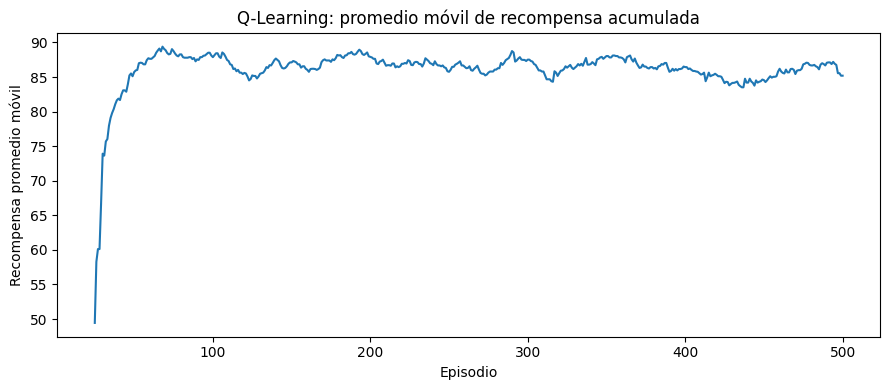

In [47]:
# Gráfico de recompensa acumulada por episodio
ax = resultados_qlearning.plot(
    x='episodio',
    y='recompensa_acumulada',
    figsize=(9, 4),
    legend=False
)
ax.set_title('Q-Learning: recompensa acumulada por episodio')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa acumulada')
plt.tight_layout()
plt.show()

# Promedio móvil para observar mejor la tendencia
resultados_qlearning['recompensa_promedio_movil'] = resultados_qlearning['recompensa_acumulada'].rolling(25).mean()
ax = resultados_qlearning.plot(
    x='episodio',
    y='recompensa_promedio_movil',
    figsize=(9, 4),
    legend=False
)
ax.set_title('Q-Learning: promedio móvil de recompensa acumulada')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa promedio móvil')
plt.tight_layout()
plt.show()


## 13. Política aprendida

Con la tabla Q entrenada se obtiene la mejor acción para cada celda visitable del almacén. Esto permite revisar visualmente la política que aprendió el agente.


In [48]:
flechas = {
    'arriba': '↑',
    'abajo': '↓',
    'izquierda': '←',
    'derecha': '→'
}

def mejor_accion(estado):
    valores = [Q[(estado, accion)] for accion in acciones]
    return acciones[int(np.argmax(valores))]

politica = cells_map[['fila', 'columna', 'estado_id', 'simbolo_celda', 'tipo_zona']].copy()

def simbolo_politica(fila):
    if fila['simbolo_celda'] == 'X':
        return 'X'
    if fila['simbolo_celda'] == 'S':
        return 'S'
    if fila['simbolo_celda'] == 'G':
        return 'G'
    accion = mejor_accion(fila['estado_id'])
    return flechas[accion]

politica['politica_aprendida'] = politica.apply(simbolo_politica, axis=1)

tabla_politica = politica.pivot(index='fila', columns='columna', values='politica_aprendida')
display(tabla_politica)


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↑,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,↓,X,↓
4,X,→,→,→,G


## 14. Prueba de la ruta aprendida

Finalmente, se ejecuta una prueba usando solo la mejor acción aprendida en cada estado. Con esto se revisa si el agente logra llegar desde el inicio hasta la zona de entrega.


In [49]:
estado = estado_inicial
ruta = [estado]
recompensa_total = 0

for _ in range(max_pasos):
    accion = mejor_accion(estado)
    siguiente_estado, recompensa, terminado, evento = transiciones[(estado, accion)]
    recompensa_total += recompensa
    ruta.append(siguiente_estado)
    estado = siguiente_estado

    if terminado:
        break

print('Ruta encontrada por la política aprendida:')
for paso, estado in enumerate(ruta):
    print(paso, estado)

print('Llegó a la zona de entrega:', ruta[-1] == estado_meta)
print('Cantidad de pasos:', len(ruta) - 1)
print('Recompensa total de la ruta:', recompensa_total)


Ruta encontrada por la política aprendida:
0 almacen_5x5_baja_r0_c0
1 almacen_5x5_baja_r0_c1
2 almacen_5x5_baja_r0_c2
3 almacen_5x5_baja_r1_c2
4 almacen_5x5_baja_r2_c2
5 almacen_5x5_baja_r2_c3
6 almacen_5x5_baja_r2_c4
7 almacen_5x5_baja_r3_c4
8 almacen_5x5_baja_r4_c4
Llegó a la zona de entrega: True
Cantidad de pasos: 8
Recompensa total de la ruta: 93.0


## 15. Continuación Experimental

Se definen parámetros comunes para ejecutar los modelos bajo condiciones similares.


In [50]:
# Configuración general para el Avance 3
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

acciones = ['arriba', 'abajo', 'izquierda', 'derecha']

config_base = {
    'episodios': 500,
    'alpha': 0.1,
    'gamma': 0.9,
    'epsilon': 0.2,
    'semilla': SEED
}

mapas_experimento = [
    'almacen_5x5_baja',
    'almacen_8x8_media',
    'almacen_10x10_alta'
]

print('Configuración base:', config_base)
print('Mapas a evaluar:', mapas_experimento)


Configuración base: {'episodios': 500, 'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'semilla': 42}
Mapas a evaluar: ['almacen_5x5_baja', 'almacen_8x8_media', 'almacen_10x10_alta']


## 16. Funciones para el entorno y la evaluación

Se crean funciones reutilizables para preparar el entorno, elegir acciones, calcular métricas, obtener la política aprendida y probar la ruta final de cada modelo.


In [51]:
def preparar_entorno(almacen_id):
    cells_map = cells_df[cells_df['almacen_id'] == almacen_id].copy()
    trans_map = trans_df[trans_df['almacen_id'] == almacen_id].copy()

    estados_validos = sorted(cells_map[~cells_map['es_obstaculo']]['estado_id'].tolist())
    estado_inicial = cells_map.loc[cells_map['simbolo_celda'] == 'S', 'estado_id'].iloc[0]
    estado_meta = cells_map.loc[cells_map['simbolo_celda'] == 'G', 'estado_id'].iloc[0]
    max_pasos = int(cells_map['max_pasos_episodio'].max())

    transiciones = {
        (fila.estado_id, fila.accion): (
            fila.siguiente_estado_id,
            float(fila.recompensa),
            bool(fila.terminado),
            fila.evento
        )
        for fila in trans_map.itertuples(index=False)
    }

    return {
        'almacen_id': almacen_id,
        'cells_map': cells_map,
        'trans_map': trans_map,
        'estados_validos': estados_validos,
        'estado_inicial': estado_inicial,
        'estado_meta': estado_meta,
        'max_pasos': max_pasos,
        'transiciones': transiciones
    }


def inicializar_q(estados_validos):
    return {
        (estado, accion): 0.0
        for estado in estados_validos
        for accion in acciones
    }


def elegir_accion_tabla(Q, estado, epsilon_actual):
    if random.random() < epsilon_actual:
        return random.choice(acciones)

    valores = [Q[(estado, accion)] for accion in acciones]
    valor_maximo = max(valores)
    mejores_acciones = [accion for accion, valor in zip(acciones, valores) if valor == valor_maximo]
    return random.choice(mejores_acciones)


def mejor_accion_tabla(Q, estado):
    valores = [Q[(estado, accion)] for accion in acciones]
    valor_maximo = max(valores)
    mejores_acciones = [accion for accion, valor in zip(acciones, valores) if valor == valor_maximo]
    return random.choice(mejores_acciones)


def calcular_metricas(resultados, nombre_modelo, almacen_id):
    ultimos = resultados.tail(100)
    return {
        'modelo': nombre_modelo,
        'almacen_id': almacen_id,
        'recompensa_promedio': resultados['recompensa_acumulada'].mean(),
        'recompensa_ultimos_100': ultimos['recompensa_acumulada'].mean(),
        'pasos_promedio': resultados['pasos'].mean(),
        'pasos_ultimos_100': ultimos['pasos'].mean(),
        'tasa_exito': resultados['exito'].mean(),
        'tasa_exito_ultimos_100': ultimos['exito'].mean()
    }


def obtener_politica(Q, entorno):
    flechas = {
        'arriba': '↑',
        'abajo': '↓',
        'izquierda': '←',
        'derecha': '→'
    }

    politica = entorno['cells_map'][['fila', 'columna', 'estado_id', 'simbolo_celda', 'tipo_zona']].copy()

    def simbolo_politica(fila):
        if fila['simbolo_celda'] == 'X':
            return 'X'
        if fila['simbolo_celda'] == 'S':
            return 'S'
        if fila['simbolo_celda'] == 'G':
            return 'G'
        accion = mejor_accion_tabla(Q, fila['estado_id'])
        return flechas[accion]

    politica['politica_aprendida'] = politica.apply(simbolo_politica, axis=1)
    return politica.pivot(index='fila', columns='columna', values='politica_aprendida')


def probar_ruta(Q, entorno):
    estado = entorno['estado_inicial']
    ruta = [estado]
    recompensa_total = 0
    eventos = []
    visitados = set()
    ciclo_detectado = False

    for _ in range(entorno['max_pasos']):
        accion = mejor_accion_tabla(Q, estado)
        siguiente_estado, recompensa, terminado, evento = entorno['transiciones'][(estado, accion)]

        recompensa_total += recompensa
        eventos.append(evento)
        ruta.append(siguiente_estado)

        if siguiente_estado in visitados and not terminado:
            ciclo_detectado = True
        visitados.add(siguiente_estado)

        estado = siguiente_estado
        if terminado:
            break

    return {
        'llego_meta': ruta[-1] == entorno['estado_meta'],
        'pasos': len(ruta) - 1,
        'recompensa_total': recompensa_total,
        'ruta': ruta,
        'eventos': eventos,
        'ciclo_detectado': ciclo_detectado
    }


## 17. Modelo 1: Q-Learning

A continuación se implementa Q-Learning como modelo base para el experimento comparativo.


In [52]:
def entrenar_qlearning(almacen_id, episodios=500, alpha=0.1, gamma=0.9, epsilon=0.2, semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)

    entorno = preparar_entorno(almacen_id)
    Q = inicializar_q(entorno['estados_validos'])
    historial = []

    for episodio in range(1, episodios + 1):
        estado = entorno['estado_inicial']
        recompensa_total = 0
        pasos = 0
        exito = False

        for _ in range(entorno['max_pasos']):
            accion = elegir_accion_tabla(Q, estado, epsilon)
            siguiente_estado, recompensa, terminado, evento = entorno['transiciones'][(estado, accion)]

            max_q_siguiente = max(Q[(siguiente_estado, a)] for a in acciones)
            Q[(estado, accion)] += alpha * (recompensa + gamma * max_q_siguiente - Q[(estado, accion)])

            recompensa_total += recompensa
            pasos += 1
            estado = siguiente_estado

            if terminado:
                exito = True
                break

        historial.append({
            'episodio': episodio,
            'modelo': 'Q-Learning',
            'almacen_id': almacen_id,
            'recompensa_acumulada': recompensa_total,
            'pasos': pasos,
            'exito': exito
        })

    return Q, pd.DataFrame(historial), entorno


## 18. Modelo 2: SARSA

Se implementa SARSA como segundo modelo comparativo para el experimento.


In [53]:
def entrenar_sarsa(almacen_id, episodios=500, alpha=0.1, gamma=0.9, epsilon=0.2, semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)

    entorno = preparar_entorno(almacen_id)
    Q = inicializar_q(entorno['estados_validos'])
    historial = []

    for episodio in range(1, episodios + 1):
        estado = entorno['estado_inicial']
        accion = elegir_accion_tabla(Q, estado, epsilon)
        recompensa_total = 0
        pasos = 0
        exito = False

        for _ in range(entorno['max_pasos']):
            siguiente_estado, recompensa, terminado, evento = entorno['transiciones'][(estado, accion)]
            siguiente_accion = elegir_accion_tabla(Q, siguiente_estado, epsilon)

            Q[(estado, accion)] += alpha * (
                recompensa + gamma * Q[(siguiente_estado, siguiente_accion)] - Q[(estado, accion)]
            )

            recompensa_total += recompensa
            pasos += 1
            estado = siguiente_estado
            accion = siguiente_accion

            if terminado:
                exito = True
                break

        historial.append({
            'episodio': episodio,
            'modelo': 'SARSA',
            'almacen_id': almacen_id,
            'recompensa_acumulada': recompensa_total,
            'pasos': pasos,
            'exito': exito
        })

    return Q, pd.DataFrame(historial), entorno


## 19. Modelo 3: Monte Carlo 

Se implementa Monte Carlo como tercer modelo comparativo para el experimento.


In [54]:
def entrenar_monte_carlo(almacen_id, episodios=500, gamma=0.9, epsilon=0.2, semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)

    entorno = preparar_entorno(almacen_id)
    Q = inicializar_q(entorno['estados_validos'])
    retornos = {clave: [] for clave in Q.keys()}
    historial = []

    for episodio in range(1, episodios + 1):
        estado = entorno['estado_inicial']
        trayectoria = []
        recompensa_total = 0
        pasos = 0
        exito = False

        for _ in range(entorno['max_pasos']):
            accion = elegir_accion_tabla(Q, estado, epsilon)
            siguiente_estado, recompensa, terminado, evento = entorno['transiciones'][(estado, accion)]

            trayectoria.append((estado, accion, recompensa))
            recompensa_total += recompensa
            pasos += 1
            estado = siguiente_estado

            if terminado:
                exito = True
                break

        G = 0
        visitados = set()
        for estado_t, accion_t, recompensa_t in reversed(trayectoria):
            G = gamma * G + recompensa_t
            par_estado_accion = (estado_t, accion_t)

            # First-visit Monte Carlo
            if par_estado_accion not in visitados:
                retornos[par_estado_accion].append(G)
                Q[par_estado_accion] = np.mean(retornos[par_estado_accion])
                visitados.add(par_estado_accion)

        historial.append({
            'episodio': episodio,
            'modelo': 'Monte Carlo',
            'almacen_id': almacen_id,
            'recompensa_acumulada': recompensa_total,
            'pasos': pasos,
            'exito': exito
        })

    return Q, pd.DataFrame(historial), entorno


## 20. Comparación inicial de modelos

Se entrenan Q-Learning, SARSA y Monte Carlo usando la misma configuración base. La comparación se realiza en los tres almacenes para observar cómo cambia el comportamiento de los algoritmos según la dificultad del entorno.


In [55]:
# Comparación inicial en el almacén base del Avance 2
almacen_base = 'almacen_5x5_baja'

Q_q, res_q, ent_q = entrenar_qlearning(almacen_base, **config_base)
Q_s, res_s, ent_s = entrenar_sarsa(almacen_base, **config_base)
Q_mc, res_mc, ent_mc = entrenar_monte_carlo(
    almacen_base,
    episodios=config_base['episodios'],
    gamma=config_base['gamma'],
    epsilon=config_base['epsilon'],
    semilla=config_base['semilla']
)

metricas_iniciales = pd.DataFrame([
    calcular_metricas(res_q, 'Q-Learning', almacen_base),
    calcular_metricas(res_s, 'SARSA', almacen_base),
    calcular_metricas(res_mc, 'Monte Carlo', almacen_base)
])

display(metricas_iniciales)


,modelo,almacen_id,recompensa_promedio,recompensa_ultimos_100,pasos_promedio,pasos_ultimos_100,tasa_exito,tasa_exito_ultimos_100
0,Q-Learning,almacen_5x5_baja,84.680,85.18,10.770,10.26,0.994,1.0
1,SARSA,almacen_5x5_baja,85.054,87.59,10.788,9.78,0.998,1.0
2,Monte Carlo,almacen_5x5_baja,81.202,85.51,11.168,10.53,0.988,1.0


In [56]:
# Entrenamiento de los tres modelos en los tres escenarios
resultados_todos = []
metricas_todos = []
modelos_entrenados = {}

for mapa_id in mapas_experimento:
    Q_q, res_q, ent_q = entrenar_qlearning(mapa_id, **config_base)
    Q_s, res_s, ent_s = entrenar_sarsa(mapa_id, **config_base)
    Q_mc, res_mc, ent_mc = entrenar_monte_carlo(
        mapa_id,
        episodios=config_base['episodios'],
        gamma=config_base['gamma'],
        epsilon=config_base['epsilon'],
        semilla=config_base['semilla']
    )

    resultados_todos.extend([res_q, res_s, res_mc])
    metricas_todos.extend([
        calcular_metricas(res_q, 'Q-Learning', mapa_id),
        calcular_metricas(res_s, 'SARSA', mapa_id),
        calcular_metricas(res_mc, 'Monte Carlo', mapa_id)
    ])

    modelos_entrenados[(mapa_id, 'Q-Learning')] = (Q_q, ent_q)
    modelos_entrenados[(mapa_id, 'SARSA')] = (Q_s, ent_s)
    modelos_entrenados[(mapa_id, 'Monte Carlo')] = (Q_mc, ent_mc)

resultados_comparacion = pd.concat(resultados_todos, ignore_index=True)
metricas_comparacion = pd.DataFrame(metricas_todos)

display(metricas_comparacion)


,modelo,almacen_id,recompensa_promedio,recompensa_ultimos_100,pasos_promedio,pasos_ultimos_100,tasa_exito,tasa_exito_ultimos_100
0,Q-Learning,almacen_5x5_baja,84.680,85.18,10.770,10.26,0.994,1.0
1,SARSA,almacen_5x5_baja,85.054,87.59,10.788,9.78,0.998,1.0
2,Monte Carlo,almacen_5x5_baja,81.202,85.51,11.168,10.53,0.988,1.0
3,Q-Learning,almacen_8x8_media,22.568,61.14,39.404,22.59,0.880,1.0
4,SARSA,almacen_8x8_media,13.022,61.88,43.368,21.67,0.848,1.0
5,Monte Carlo,almacen_8x8_media,-579.022,-583.05,128.000,128.00,0.000,0.0
6,Q-Learning,almacen_10x10_alta,50.794,69.46,32.970,22.59,0.988,1.0
7,SARSA,almacen_10x10_alta,47.564,69.39,34.698,22.48,0.988,1.0
8,Monte Carlo,almacen_10x10_alta,-338.224,-270.46,200.000,200.00,0.000,0.0


## 21. Visualización de resultados iniciales

Se comparan las recompensas acumuladas y el promedio móvil de los tres modelos.


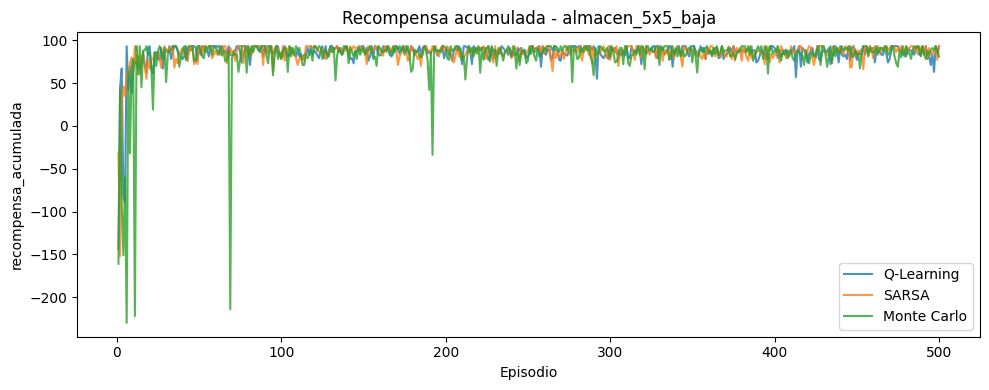

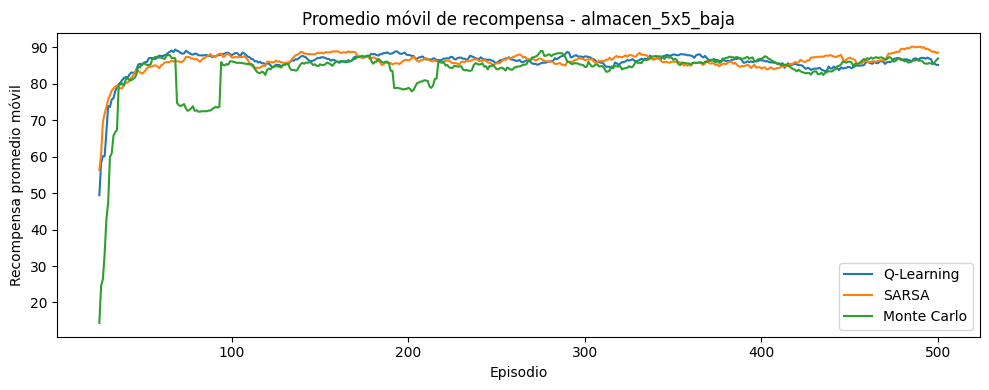

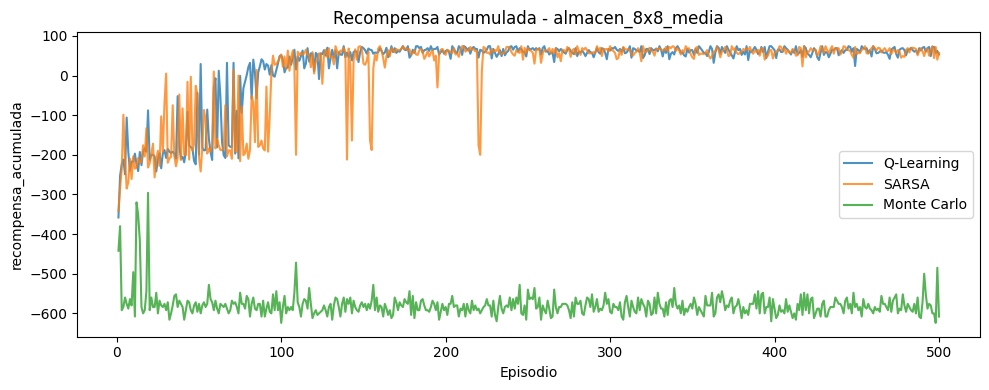

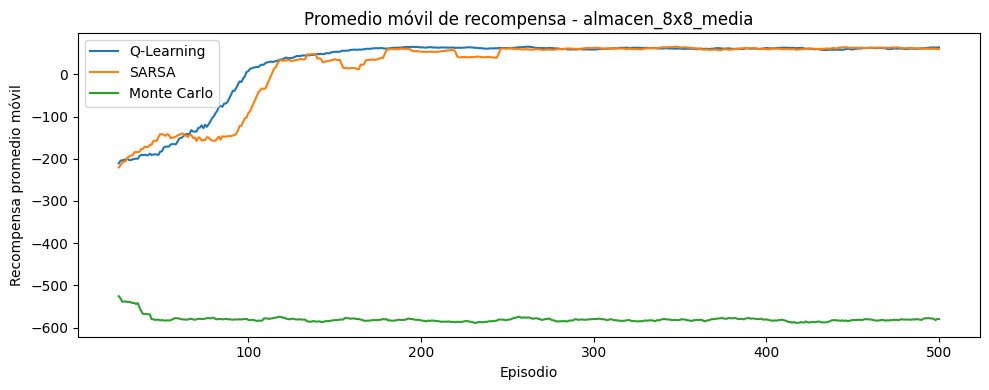

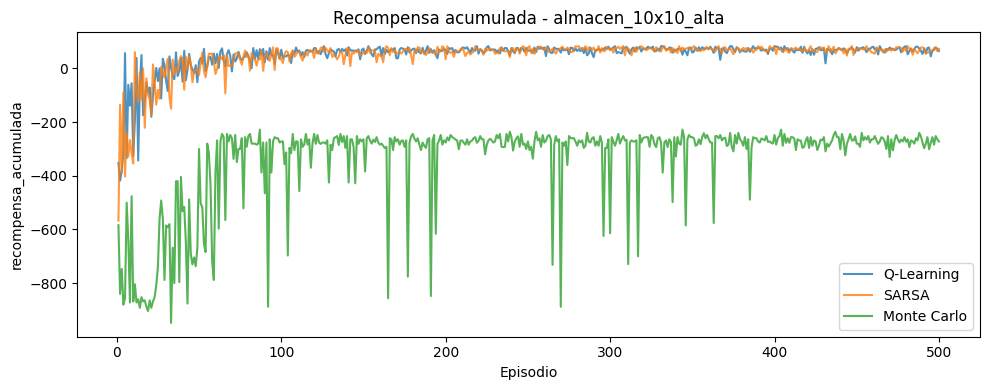

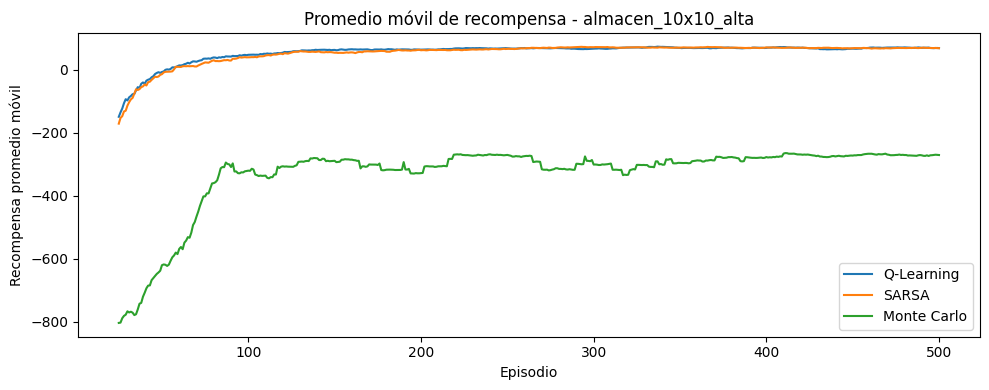

In [57]:
def graficar_modelos(resultados, almacen_id, columna='recompensa_acumulada', titulo=''):
    datos = resultados[resultados['almacen_id'] == almacen_id].copy()
    fig, ax = plt.subplots(figsize=(10, 4))

    for modelo in datos['modelo'].unique():
        sub = datos[datos['modelo'] == modelo]
        ax.plot(sub['episodio'], sub[columna], label=modelo, alpha=0.8)

    ax.set_title(titulo if titulo else f'{columna} por episodio - {almacen_id}')
    ax.set_xlabel('Episodio')
    ax.set_ylabel(columna)
    ax.legend()
    plt.tight_layout()
    plt.show()


def graficar_promedio_movil(resultados, almacen_id, ventana=25):
    datos = resultados[resultados['almacen_id'] == almacen_id].copy()
    fig, ax = plt.subplots(figsize=(10, 4))

    for modelo in datos['modelo'].unique():
        sub = datos[datos['modelo'] == modelo].copy()
        sub['promedio_movil'] = sub['recompensa_acumulada'].rolling(ventana).mean()
        ax.plot(sub['episodio'], sub['promedio_movil'], label=modelo)

    ax.set_title(f'Promedio móvil de recompensa - {almacen_id}')
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Recompensa promedio móvil')
    ax.legend()
    plt.tight_layout()
    plt.show()

for mapa_id in mapas_experimento:
    graficar_modelos(resultados_comparacion, mapa_id, 'recompensa_acumulada', f'Recompensa acumulada - {mapa_id}')
    graficar_promedio_movil(resultados_comparacion, mapa_id)


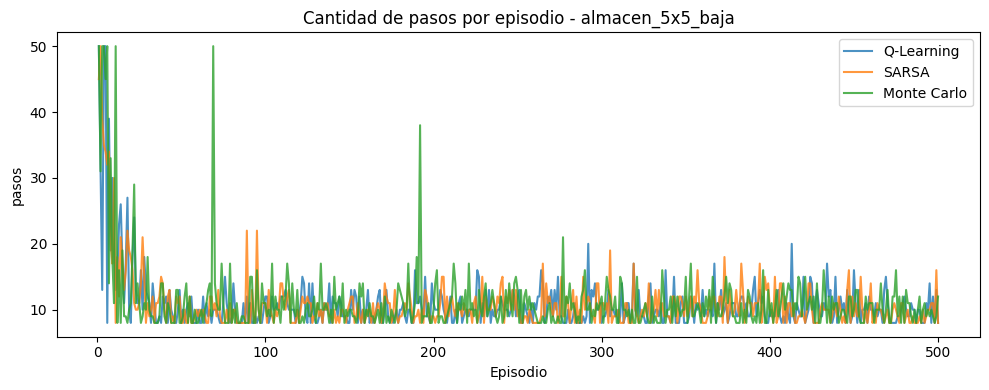

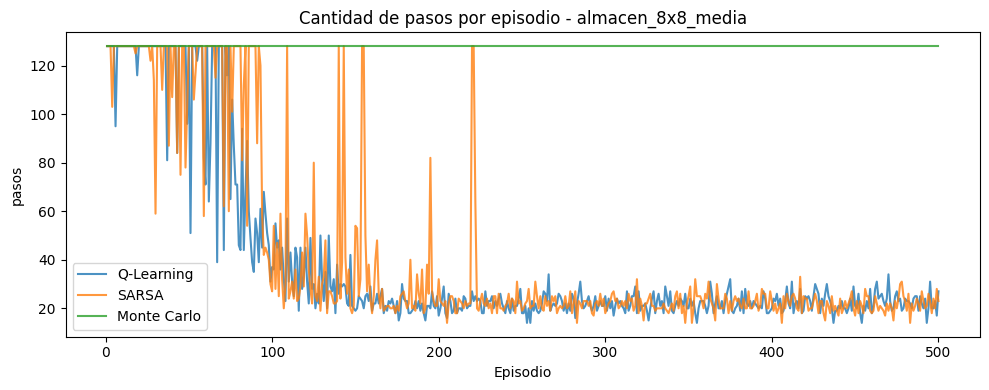

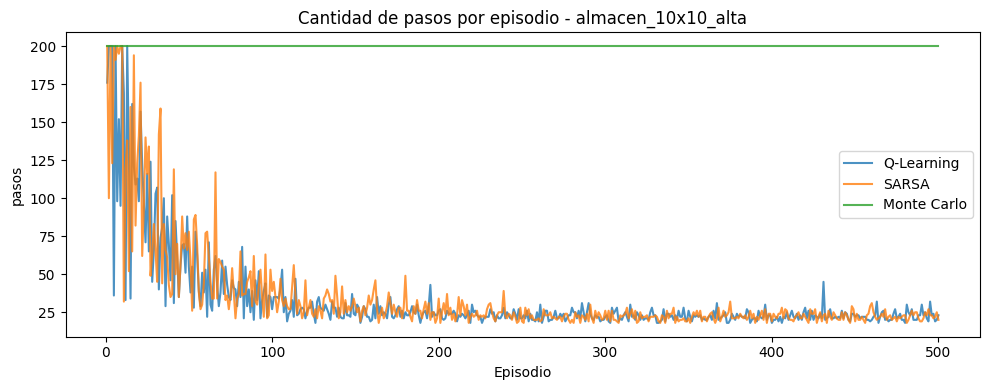

In [58]:
# Comparación de pasos promedio por episodio
for mapa_id in mapas_experimento:
    graficar_modelos(resultados_comparacion, mapa_id, 'pasos', f'Cantidad de pasos por episodio - {mapa_id}')


### Análisis de convergencia

La convergencia se analizó observando la evolución de la recompensa durante el entrenamiento y el comportamiento de los últimos 100 episodios. Si la recompensa se mantiene alta y la tasa de éxito llega a 1.0 en la etapa final, se considera que el modelo logró estabilizar una política funcional.

En los resultados se observa que Q-Learning y SARSA logran estabilizarse en los tres escenarios. Aunque al inicio presentan variaciones por la exploración, en los últimos episodios ambos modelos alcanzan tasas de éxito altas y rutas funcionales hacia la zona de entrega.

Monte Carlo muestra un comportamiento distinto. En el escenario almacen_5x5_baja logra estabilizarse, pero en los escenarios almacen_8x8_media y almacen_10x10_alta mantiene recompensas negativas y no alcanza una política funcional. Esto indica que no logra converger correctamente en los mapas de mayor dificultad.

## 22. Comparación de políticas aprendidas

Se visualiza la política aprendida por cada algoritmo.


In [59]:
for mapa_id in mapas_experimento:
    print('\nMapa:', mapa_id)
    for modelo in ['Q-Learning', 'SARSA', 'Monte Carlo']:
        Q_modelo, entorno_modelo = modelos_entrenados[(mapa_id, modelo)]
        print('\nPolítica aprendida:', modelo)
        display(obtener_politica(Q_modelo, entorno_modelo))



Mapa: almacen_5x5_baja

Política aprendida: Q-Learning


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↑,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,↓,X,↓
4,X,→,→,→,G



Política aprendida: SARSA


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↑,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,↓,X,↓
4,X,→,→,→,G



Política aprendida: Monte Carlo


...

columna,0,1,2,3,4,5,6,7,8,9
fila,,,,,,,,,,
0,S,→,↓,X,↓,→,→,→,→,↓
1,↑,X,↓,X,↓,X,X,X,↓,↓
2,↓,X,→,→,↓,←,→,↑,→,↓
3,↓,X,X,X,↓,X,X,X,X,↓
4,→,→,↓,→,→,→,→,↓,X,↓
5,X,X,↓,X,X,X,X,↓,X,↓
6,↓,→,↓,X,↓,←,→,↓,X,↓
7,↑,X,→,→,↓,X,X,→,→,↓
8,↓,X,X,X,→,→,→,↓,X,↓



Política aprendida: SARSA


columna,0,1,2,3,4,5,6,7,8,9
fila,,,,,,,,,,
0,S,→,↓,X,→,→,←,←,↓,↓
1,↓,X,↓,X,↓,X,X,X,↓,↓
2,↓,X,→,→,↓,←,→,→,→,↓
3,↓,X,X,X,↓,X,X,X,X,↓
4,→,→,↓,→,→,→,→,↓,X,↓
5,X,X,↓,X,X,X,X,↓,X,↓
6,↓,→,↓,X,↓,←,→,↓,X,↓
7,↓,X,→,→,↓,X,X,↓,←,↓
8,↓,X,X,X,→,→,→,↓,X,↓



Política aprendida: Monte Carlo


columna,0,1,2,3,4,5,6,7,8,9
fila,,,,,,,,,,
0,S,←,↑,X,→,→,→,←,←,↑
1,↓,X,↓,X,→,X,X,X,↓,←
2,↓,X,←,↓,↑,←,→,→,→,←
3,↓,X,X,X,←,X,X,X,X,↑
4,→,→,↓,←,←,→,←,←,X,↑
5,X,X,↓,X,X,X,X,↑,X,↓
6,→,→,↑,X,↓,←,←,↑,X,↓
7,←,X,→,←,←,X,X,→,→,←
8,←,X,X,X,↑,←,↓,←,X,↓


## 23. Prueba final de rutas aprendidas

Se ejecuta una prueba final sin exploración aleatoria. El agente usa solo la mejor acción aprendida en cada estado.


In [60]:
rutas_finales = []

for mapa_id in mapas_experimento:
    for modelo in ['Q-Learning', 'SARSA', 'Monte Carlo']:
        Q_modelo, entorno_modelo = modelos_entrenados[(mapa_id, modelo)]
        prueba = probar_ruta(Q_modelo, entorno_modelo)
        rutas_finales.append({
            'modelo': modelo,
            'almacen_id': mapa_id,
            'llego_meta': prueba['llego_meta'],
            'pasos_ruta_final': prueba['pasos'],
            'recompensa_ruta_final': prueba['recompensa_total'],
            'ciclo_detectado': prueba['ciclo_detectado'],
            'eventos': ', '.join(prueba['eventos'][:10])
        })

rutas_finales_df = pd.DataFrame(rutas_finales)
display(rutas_finales_df)


,modelo,almacen_id,llego_meta,pasos_ruta_final,recompensa_ruta_final,ciclo_detectado,eventos
0,Q-Learning,almacen_5x5_baja,True,8,93.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
1,SARSA,almacen_5x5_baja,True,8,93.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
2,Monte Carlo,almacen_5x5_baja,True,8,93.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
3,Q-Learning,almacen_8x8_media,True,18,74.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
4,SARSA,almacen_8x8_media,True,18,74.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
5,Monte Carlo,almacen_8x8_media,False,128,-640.0,True,"fuera_del_almacen, fuera_del_almacen, fuera_de..."
6,Q-Learning,almacen_10x10_alta,True,18,83.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
7,SARSA,almacen_10x10_alta,True,18,83.0,False,"movimiento_por_pasillo, movimiento_por_pasillo..."
8,Monte Carlo,almacen_10x10_alta,False,200,-200.0,True,"movimiento_por_pasillo, movimiento_por_pasillo..."


## 24. Optimización simple de hiperparámetros

Se realiza una búsqueda manual pequeña para observar si los modelos pueden mejorar respecto a la configuración base. 


In [61]:
# Búsqueda manual liviana para no alargar demasiado el tiempo de ejecución
alphas = [0.1, 0.2]
gammas = [0.8, 0.9]
epsilons = [0.1, 0.2, 0.3]
episodios_opt = 500

almacen_opt = 'almacen_5x5_baja'
resultados_optimizacion = []

for modelo in ['Q-Learning', 'SARSA']:
    for alpha_opt in alphas:
        for gamma_opt in gammas:
            for epsilon_opt in epsilons:
                if modelo == 'Q-Learning':
                    Q_tmp, res_tmp, ent_tmp = entrenar_qlearning(
                        almacen_opt,
                        episodios=episodios_opt,
                        alpha=alpha_opt,
                        gamma=gamma_opt,
                        epsilon=epsilon_opt,
                        semilla=SEED
                    )
                else:
                    Q_tmp, res_tmp, ent_tmp = entrenar_sarsa(
                        almacen_opt,
                        episodios=episodios_opt,
                        alpha=alpha_opt,
                        gamma=gamma_opt,
                        epsilon=epsilon_opt,
                        semilla=SEED
                    )

                met = calcular_metricas(res_tmp, modelo, almacen_opt)
                met.update({'alpha': alpha_opt, 'gamma': gamma_opt, 'epsilon': epsilon_opt})
                resultados_optimizacion.append(met)

# Monte Carlo no usa alpha en esta implementación
for gamma_opt in gammas:
    for epsilon_opt in epsilons:
        Q_tmp, res_tmp, ent_tmp = entrenar_monte_carlo(
            almacen_opt,
            episodios=episodios_opt,
            gamma=gamma_opt,
            epsilon=epsilon_opt,
            semilla=SEED
        )
        met = calcular_metricas(res_tmp, 'Monte Carlo', almacen_opt)
        met.update({'alpha': None, 'gamma': gamma_opt, 'epsilon': epsilon_opt})
        resultados_optimizacion.append(met)

opt_df = pd.DataFrame(resultados_optimizacion)
opt_df = opt_df.sort_values(
    by=['tasa_exito_ultimos_100', 'recompensa_ultimos_100', 'pasos_ultimos_100'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(opt_df.head(10))


,modelo,almacen_id,recompensa_promedio,recompensa_ultimos_100,pasos_promedio,pasos_ultimos_100,tasa_exito,tasa_exito_ultimos_100,alpha,gamma,epsilon
0,SARSA,almacen_5x5_baja,88.100,90.28,9.676,8.91,0.994,1.0,0.1,0.9,0.1
1,SARSA,almacen_5x5_baja,88.600,90.27,9.402,8.88,0.996,1.0,0.2,0.9,0.1
2,SARSA,almacen_5x5_baja,88.758,90.22,9.384,8.89,0.996,1.0,0.2,0.8,0.1
3,Q-Learning,almacen_5x5_baja,88.922,90.04,9.364,8.99,0.996,1.0,0.2,0.8,0.1
4,Q-Learning,almacen_5x5_baja,88.410,89.83,9.590,9.11,0.996,1.0,0.1,0.9,0.1
5,SARSA,almacen_5x5_baja,87.726,89.68,9.616,8.95,0.994,1.0,0.1,0.8,0.1
6,Q-Learning,almacen_5x5_baja,88.242,89.41,9.624,9.09,0.996,1.0,0.1,0.8,0.1
7,Q-Learning,almacen_5x5_baja,88.890,89.29,9.318,9.03,0.998,1.0,0.2,0.9,0.1
8,SARSA,almacen_5x5_baja,85.054,87.59,10.788,9.78,0.998,1.0,0.1,0.9,0.2
9,SARSA,almacen_5x5_baja,85.210,87.30,10.644,10.00,0.998,1.0,0.2,0.9,0.2


### Exploración y explotación

La exploración y explotación se controló mediante el parámetro epsilon. Cuando epsilon es más alto, el agente prueba más acciones aleatorias, lo que ayuda a explorar rutas nuevas durante el entrenamiento. Sin embargo, si la exploración se mantiene alta, el agente puede seguir tomando decisiones innecesarias incluso cuando ya encontró una ruta funcional.

En la optimización simple se observó que reducir epsilon ayudó especialmente a Q-Learning y SARSA. Con un valor menor de exploración, los modelos aprovecharon mejor la política aprendida y redujeron movimientos aleatorios en el escenario base. Esto permitió mejorar la recompensa promedio y disminuir la cantidad de pasos.

En el caso de Monte Carlo, la exploración no fue suficiente para resolver los escenarios más grandes, ya que este algoritmo depende de episodios completos para actualizar sus valores. Por esto, aunque puede funcionar en el mapa simple, presenta más dificultades cuando el entorno aumenta de tamaño.

## 25. Comparación final con mejores configuraciones

Se selecciona la mejor configuración encontrada para cada modelo en el escenario base y se comparan sus resultados.


In [62]:
mejores_configuraciones = (
    opt_df.sort_values(
        by=['modelo', 'tasa_exito_ultimos_100', 'recompensa_ultimos_100', 'pasos_ultimos_100'],
        ascending=[True, False, False, True]
    )
    .groupby('modelo')
    .head(1)
    .reset_index(drop=True)
)

display(mejores_configuraciones[['modelo', 'alpha', 'gamma', 'epsilon', 'recompensa_ultimos_100', 'pasos_ultimos_100', 'tasa_exito_ultimos_100']])


,modelo,alpha,gamma,epsilon,recompensa_ultimos_100,pasos_ultimos_100,tasa_exito_ultimos_100
0,Monte Carlo,NaN,0.8,0.2,85.81,10.54,1.0
1,Q-Learning,0.2,0.8,0.1,90.04,8.99,1.0
2,SARSA,0.1,0.9,0.1,90.28,8.91,1.0


,modelo,almacen_id,recompensa_promedio,recompensa_ultimos_100,pasos_promedio,pasos_ultimos_100,tasa_exito,tasa_exito_ultimos_100
0,Monte Carlo,almacen_5x5_baja,82.492,85.81,11.270,10.54,0.984,1.0
1,Q-Learning,almacen_5x5_baja,88.922,90.04,9.364,8.99,0.996,1.0
2,SARSA,almacen_5x5_baja,88.100,90.28,9.676,8.91,0.994,1.0


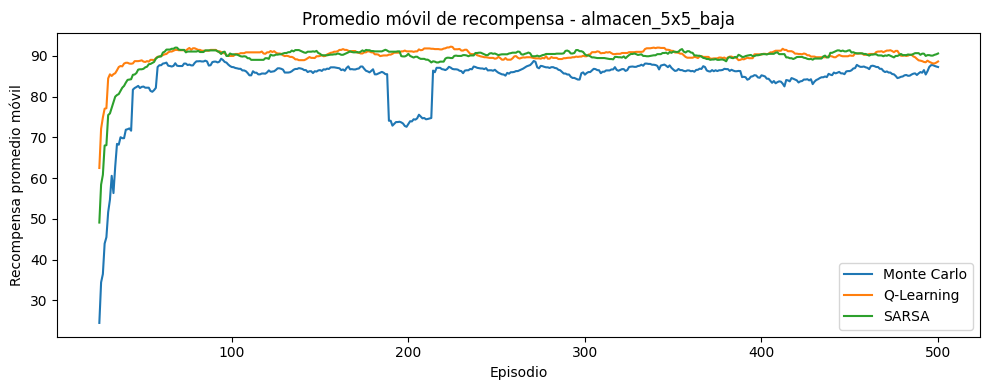

In [63]:
# Entrenamiento final de cada modelo con su mejor configuración en el mapa base
resultados_finales = []
modelos_finales = {}

for fila in mejores_configuraciones.itertuples(index=False):
    modelo = fila.modelo
    alpha_best = fila.alpha
    gamma_best = fila.gamma
    epsilon_best = fila.epsilon

    if modelo == 'Q-Learning':
        Q_best, res_best, ent_best = entrenar_qlearning(
            almacen_opt, episodios=episodios_opt, alpha=alpha_best,
            gamma=gamma_best, epsilon=epsilon_best, semilla=SEED
        )
    elif modelo == 'SARSA':
        Q_best, res_best, ent_best = entrenar_sarsa(
            almacen_opt, episodios=episodios_opt, alpha=alpha_best,
            gamma=gamma_best, epsilon=epsilon_best, semilla=SEED
        )
    else:
        Q_best, res_best, ent_best = entrenar_monte_carlo(
            almacen_opt, episodios=episodios_opt,
            gamma=gamma_best, epsilon=epsilon_best, semilla=SEED
        )

    res_best = res_best.copy()
    res_best['configuracion'] = f'alpha={alpha_best}, gamma={gamma_best}, epsilon={epsilon_best}'
    resultados_finales.append(res_best)
    modelos_finales[modelo] = (Q_best, ent_best)

resultados_finales_df = pd.concat(resultados_finales, ignore_index=True)
metricas_finales = []

for modelo in resultados_finales_df['modelo'].unique():
    sub = resultados_finales_df[resultados_finales_df['modelo'] == modelo]
    metricas_finales.append(calcular_metricas(sub, modelo, almacen_opt))

metricas_finales_df = pd.DataFrame(metricas_finales)
display(metricas_finales_df)

graficar_promedio_movil(resultados_finales_df, almacen_opt)


## 26. Análisis de errores

Se revisan los errores más relevantes del entrenamiento: episodios sin éxito, rutas demasiado largas, ciclos y eventos asociados a movimientos no deseados.


In [64]:
analisis_errores = []

for mapa_id in mapas_experimento:
    for modelo in ['Q-Learning', 'SARSA', 'Monte Carlo']:
        sub = resultados_comparacion[
            (resultados_comparacion['almacen_id'] == mapa_id) &
            (resultados_comparacion['modelo'] == modelo)
        ].copy()
        Q_modelo, entorno_modelo = modelos_entrenados[(mapa_id, modelo)]
        prueba = probar_ruta(Q_modelo, entorno_modelo)

        analisis_errores.append({
            'modelo': modelo,
            'almacen_id': mapa_id,
            'episodios_sin_exito': int((~sub['exito']).sum()),
            'porcentaje_sin_exito': 1 - sub['exito'].mean(),
            'pasos_maximos_observados': int(sub['pasos'].max()),
            'ruta_final_llega_meta': prueba['llego_meta'],
            'ruta_final_ciclo': prueba['ciclo_detectado'],
            'pasos_ruta_final': prueba['pasos']
        })

analisis_errores_df = pd.DataFrame(analisis_errores)
display(analisis_errores_df)


,modelo,almacen_id,episodios_sin_exito,porcentaje_sin_exito,pasos_maximos_observados,ruta_final_llega_meta,ruta_final_ciclo,pasos_ruta_final
0,Q-Learning,almacen_5x5_baja,3,0.006,50,True,False,8
1,SARSA,almacen_5x5_baja,1,0.002,50,True,False,8
2,Monte Carlo,almacen_5x5_baja,6,0.012,50,True,False,8
3,Q-Learning,almacen_8x8_media,60,0.120,128,True,False,18
4,SARSA,almacen_8x8_media,76,0.152,128,True,False,18
5,Monte Carlo,almacen_8x8_media,500,1.000,128,False,True,128
6,Q-Learning,almacen_10x10_alta,6,0.012,200,True,False,18
7,SARSA,almacen_10x10_alta,6,0.012,200,True,False,18
8,Monte Carlo,almacen_10x10_alta,500,1.000,200,False,True,200


## 27. Interpretabilidad mediante política aprendida

La interpretabilidad se revisa a partir de la política aprendida. Como el almacén está representado en una grilla, se puede observar qué movimiento prefiere el agente en cada celda.

Con esto se verifica si el comportamiento aprendido es coherente, es decir, si evita obstáculos, intenta no pasar por zonas congestionadas y se dirige hacia la zona de entrega.


In [65]:
# Políticas finales optimizadas en el mapa base
for modelo, (Q_modelo, entorno_modelo) in modelos_finales.items():
    print('\nPolítica final optimizada:', modelo)
    display(obtener_politica(Q_modelo, entorno_modelo))



Política final optimizada: Monte Carlo


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↑,X,↓,X,↓
2,↑,X,→,→,↓
3,↑,→,↑,X,↓
4,X,↑,←,→,G



Política final optimizada: Q-Learning


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↓,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,↓,X,↓
4,X,→,→,→,G



Política final optimizada: SARSA


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↑
1,↓,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,←,X,↓
4,X,→,→,→,G


## 28. Evaluación con múltiples semillas

Se usaron las mismas condiciones experimentales del entrenamiento base, pero repitiendo el proceso con distintas semillas. Luego se calculó el promedio y la desviación estándar de las métricas principales. 

In [66]:
# Evaluación con múltiples semillas
semillas = [42, 123, 2026]

metricas_semillas = []

for semilla_actual in semillas:
    for mapa_id in mapas_experimento:
        Q_q, res_q, ent_q = entrenar_qlearning(
            mapa_id,
            episodios=config_base['episodios'],
            alpha=config_base['alpha'],
            gamma=config_base['gamma'],
            epsilon=config_base['epsilon'],
            semilla=semilla_actual
        )

        Q_s, res_s, ent_s = entrenar_sarsa(
            mapa_id,
            episodios=config_base['episodios'],
            alpha=config_base['alpha'],
            gamma=config_base['gamma'],
            epsilon=config_base['epsilon'],
            semilla=semilla_actual
        )

        Q_mc, res_mc, ent_mc = entrenar_monte_carlo(
            mapa_id,
            episodios=config_base['episodios'],
            gamma=config_base['gamma'],
            epsilon=config_base['epsilon'],
            semilla=semilla_actual
        )

        met_q = calcular_metricas(res_q, 'Q-Learning', mapa_id)
        met_s = calcular_metricas(res_s, 'SARSA', mapa_id)
        met_mc = calcular_metricas(res_mc, 'Monte Carlo', mapa_id)

        met_q['semilla'] = semilla_actual
        met_s['semilla'] = semilla_actual
        met_mc['semilla'] = semilla_actual

        metricas_semillas.extend([met_q, met_s, met_mc])

metricas_semillas_df = pd.DataFrame(metricas_semillas)

display(metricas_semillas_df)

,modelo,almacen_id,recompensa_promedio,recompensa_ultimos_100,pasos_promedio,pasos_ultimos_100,tasa_exito,tasa_exito_ultimos_100,semilla
0,Q-Learning,almacen_5x5_baja,84.680,85.18,10.770,10.26,0.994,1.0,42
1,SARSA,almacen_5x5_baja,85.054,87.59,10.788,9.78,0.998,1.0,42
2,Monte Carlo,almacen_5x5_baja,81.202,85.51,11.168,10.53,0.988,1.0,42
3,Q-Learning,almacen_8x8_media,22.568,61.14,39.404,22.59,0.880,1.0,42
4,SARSA,almacen_8x8_media,13.022,61.88,43.368,21.67,0.848,1.0,42
5,Monte Carlo,almacen_8x8_media,-579.022,-583.05,128.000,128.00,0.000,0.0,42
6,Q-Learning,almacen_10x10_alta,50.794,69.46,32.970,22.59,0.988,1.0,42
7,SARSA,almacen_10x10_alta,47.564,69.39,34.698,22.48,0.988,1.0,42
8,Monte Carlo,almacen_10x10_alta,-338.224,-270.46,200.000,200.00,0.000,0.0,42
9,Q-Learning,almacen_5x5_baja,84.222,85.52,10.920,10.34,0.996,1.0,123


In [67]:
# Resumen por modelo y escenario
resumen_semillas = (
    metricas_semillas_df
    .groupby(['modelo', 'almacen_id'])
    .agg({
        'recompensa_promedio': ['mean', 'std'],
        'recompensa_ultimos_100': ['mean', 'std'],
        'pasos_promedio': ['mean', 'std'],
        'tasa_exito': ['mean', 'std'],
        'tasa_exito_ultimos_100': ['mean', 'std']
    })
    .round(3)
)

display(resumen_semillas)

recompensa_promedio           \
                                              mean      std   
modelo      almacen_id                                        
Monte Carlo almacen_10x10_alta            -331.131   43.525   
            almacen_5x5_baja                41.808   69.947   
            almacen_8x8_media             -317.318  226.680   
Q-Learning  almacen_10x10_alta              51.213    1.219   
            almacen_5x5_baja                84.439    0.230   
            almacen_8x8_media               21.815    1.947   
SARSA       almacen_10x10_alta              47.564    0.016   
            almacen_5x5_baja                84.603    0.496   
            almacen_8x8_media               12.627    4.292   

                               recompensa_ultimos_100          pasos_promedio  \
                                                 mean      std           mean   
modelo      almacen_id                                                          
Monte Carlo almacen_10x10_alta               -274.687    5.176        199.999   
            almacen_5x5_baja                   66.887   32.006         21.762   
            almacen_8x8_media                -313.657  233.304        128.000   
Q-Learning  almacen_10x10_alta                 69.810    0.695         32.718   
            almacen_5x5_baja                   85.987    1.116         10.759   
            almacen_8x8_media                  61.550    1.352         39.841   
SARSA       almacen_10x10_alta                 70.243    0.921         34.691   
            almacen_5x5_baja                   86.877    0.687         10.730   
            almacen_8x8_media                  60.803    1.157         43.673   

                                       tasa_exito         \
                                   std       mean    std   
modelo      almacen_id                                     
Monte Carlo almacen_10x10_alta   0.001      0.001  0.001   
            almacen_5x5_baja    18.929      0.739  0.435   
            almacen_8x8_media    0.000      0.000  0.000   
Q-Learning  almacen_10x10_alta   0.522      0.987  0.004   
            almacen_5x5_baja     0.167      0.995  0.001   
            almacen_8x8_media    0.912      0.879  0.008   
SARSA       almacen_10x10_alta   0.021      0.987  0.002   
            almacen_5x5_baja     0.060      0.995  0.003   
            almacen_8x8_media    1.891      0.849  0.019   

                               tasa_exito_ultimos_100         
                                                 mean    std  
modelo      almacen_id                                        
Monte Carlo almacen_10x10_alta                    0.0  0.000  
            almacen_5x5_baja                      0.9  0.173  
            almacen_8x8_media                     0.0  0.000  
Q-Learning  almacen_10x10_alta                    1.0  0.000  
            almacen_5x5_baja                      1.0  0.000  
            almacen_8x8_media                     1.0  0.000  
SARSA       almacen_10x10_alta                    1.0  0.000  
            almacen_5x5_baja                      1.0  0.000  
            almacen_8x8_media                     1.0  0.000

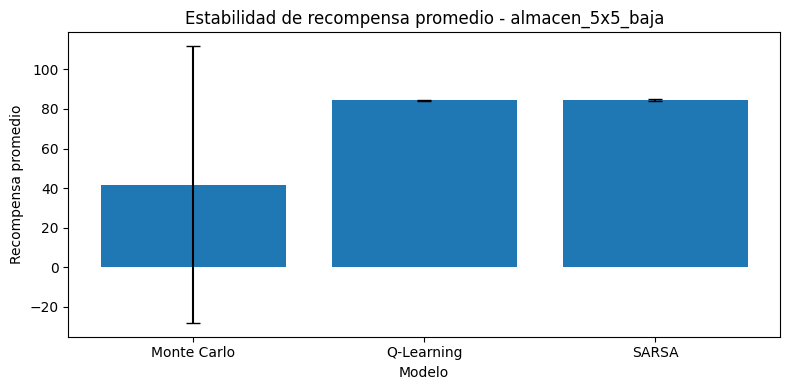

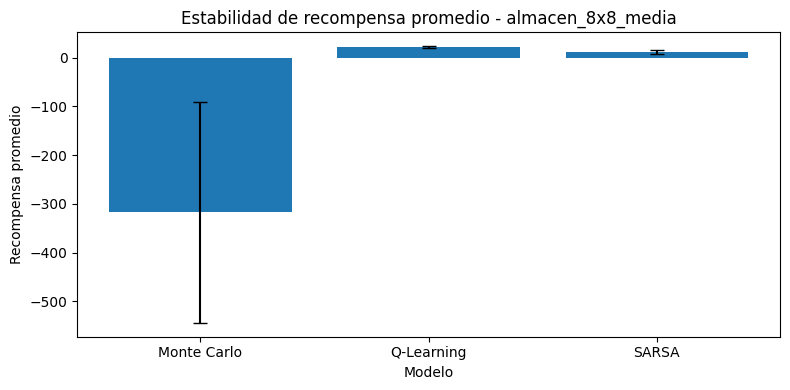

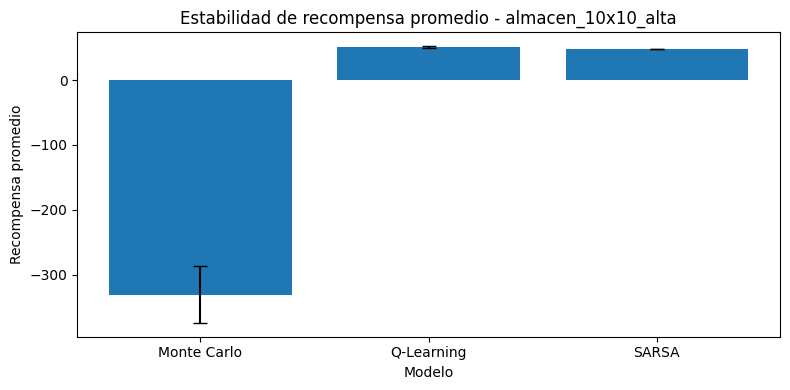

In [68]:
# Visualización de estabilidad entre semillas
resumen_plot = (
    metricas_semillas_df
    .groupby(['modelo', 'almacen_id'])
    .agg(
        recompensa_media=('recompensa_promedio', 'mean'),
        recompensa_std=('recompensa_promedio', 'std')
    )
    .reset_index()
)

for mapa_id in mapas_experimento:
    datos = resumen_plot[resumen_plot['almacen_id'] == mapa_id]

    plt.figure(figsize=(8, 4))
    plt.bar(
        datos['modelo'],
        datos['recompensa_media'],
        yerr=datos['recompensa_std'],
        capsize=5
    )
    plt.title(f'Estabilidad de recompensa promedio - {mapa_id}')
    plt.xlabel('Modelo')
    plt.ylabel('Recompensa promedio')
    plt.tight_layout()
    plt.show()

### Interpretación de la evaluación con múltiples semillas

La evaluación con múltiples semillas permitió revisar si los resultados dependían de una sola ejecución aleatoria. Para esto se usaron las semillas 42, 123 y 2026, manteniendo la misma configuración base para los tres algoritmos.

Los resultados muestran que Q-Learning y SARSA son los modelos más estables. En los tres escenarios mantienen tasas de éxito altas y desviaciones estándar bajas, por lo que su desempeño no cambia demasiado al modificar la semilla.

Monte Carlo presenta mayor variación. En el mapa almacen_5x5_baja logra funcionar en algunas ejecuciones, pero su desviación estándar es alta. En los mapas almacen_8x8_media y almacen_10x10_alta mantiene recompensas negativas y tasas de éxito cercanas a 0.0, lo que confirma que no aprende una política funcional en escenarios más complejos.

En conclusión, el uso de múltiples semillas confirma que Q-Learning y SARSA tienen un comportamiento más robusto, mientras que Monte Carlo depende más de la ejecución y presenta menor estabilidad.

## 29. Mayor realismo del almacén inteligente

A partir de la retroalimentación del Avance 2, se agregó una revisión más explícita del componente logístico del entorno. Aunque el problema mantiene una estructura tipo GridWorld, el almacén simulado no se interpreta solo como una grilla, sino como una representación simplificada de un espacio operativo.

En este entorno, las estanterías funcionan como obstáculos no transitables, los pasillos representan zonas disponibles para el desplazamiento del robot, las zonas congestionadas incorporan una penalización adicional, el punto de inicio representa la posición inicial del robot y la zona de entrega representa el objetivo logístico.

Para reforzar esta interpretación, se agregan variables operacionales simples que permiten analizar el costo logístico de las rutas aprendidas. Estas variables no cambian la estructura original del dataset, pero ayudan a interpretar los resultados desde el punto de vista de un almacén inteligente.

In [69]:
# Enriquecimiento logístico del dataset
cells_logistica = cells_df.copy()

cells_logistica['es_transitable'] = ~cells_logistica['es_obstaculo']

cells_logistica['tipo_operacional'] = cells_logistica['tipo_zona'].replace({
    'pasillo_libre': 'zona_transitable',
    'estanteria': 'zona_bloqueada',
    'zona_congestionada': 'zona_transitable_con_penalizacion',
    'inicio_robot': 'punto_inicio_operacional',
    'zona_entrega': 'punto_entrega'
})

cells_logistica['costo_logistico'] = cells_logistica['tipo_zona'].replace({
    'pasillo_libre': 1,
    'inicio_robot': 1,
    'zona_entrega': 0,
    'zona_congestionada': 4,
    'estanteria': None
})

cells_logistica['riesgo_operacional'] = cells_logistica['tipo_zona'].replace({
    'pasillo_libre': 'bajo',
    'inicio_robot': 'bajo',
    'zona_entrega': 'bajo',
    'zona_congestionada': 'medio',
    'estanteria': 'no_transitable'
})

display(cells_logistica.head())

,almacen_id,filas_almacen,columnas_almacen,estado_id,fila,columna,simbolo_celda,tipo_zona,descripcion_zona,recompensa_entrada,es_terminal,es_obstaculo,max_pasos_episodio,es_transitable,tipo_operacional,costo_logistico,riesgo_operacional
0,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,Posición inicial del robot autónomo dentro del...,-1.0,False,False,50,True,punto_inicio_operacional,1,bajo
1,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50,True,zona_transitable,1,bajo
2,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c2,0,2,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50,True,zona_transitable,1,bajo
3,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c3,0,3,X,estanteria,Estantería o zona bloqueada no transitable.,NaN,False,True,50,False,zona_bloqueada,None,no_transitable
4,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c4,0,4,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50,True,zona_transitable,1,bajo


In [70]:
# Resumen operativo por almacén
resumen_logistico = (
    cells_logistica
    .groupby(['almacen_id', 'tipo_operacional'])
    .size()
    .reset_index(name='cantidad_celdas')
)

display(resumen_logistico)

,almacen_id,tipo_operacional,cantidad_celdas
0,almacen_10x10_alta,punto_entrega,1
1,almacen_10x10_alta,punto_inicio_operacional,1
2,almacen_10x10_alta,zona_bloqueada,33
3,almacen_10x10_alta,zona_transitable,62
4,almacen_10x10_alta,zona_transitable_con_penalizacion,3
5,almacen_5x5_baja,punto_entrega,1
6,almacen_5x5_baja,punto_inicio_operacional,1
7,almacen_5x5_baja,zona_bloqueada,6
8,almacen_5x5_baja,zona_transitable,16
9,almacen_5x5_baja,zona_transitable_con_penalizacion,1


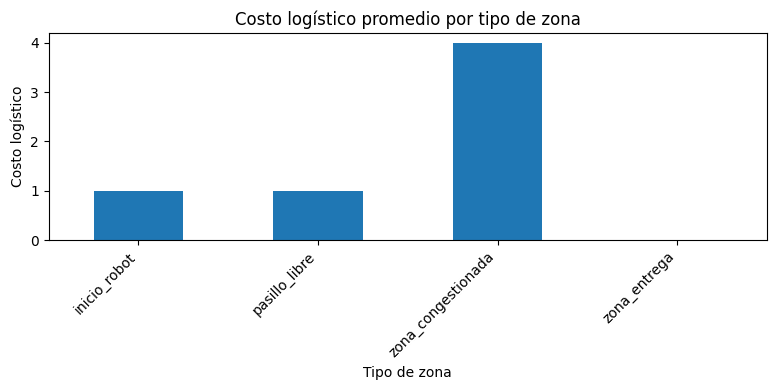

In [71]:
# Visualización del costo logístico por tipo de zona
costo_por_zona = (
    cells_logistica
    .dropna(subset=['costo_logistico'])
    .groupby('tipo_zona')['costo_logistico']
    .mean()
    .reset_index()
)

ax = costo_por_zona.plot(
    x='tipo_zona',
    y='costo_logistico',
    kind='bar',
    figsize=(8, 4),
    legend=False
)

ax.set_title('Costo logístico promedio por tipo de zona')
ax.set_xlabel('Tipo de zona')
ax.set_ylabel('Costo logístico')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [72]:
# Análisis logístico de las rutas finales aprendidas
analisis_logistico_rutas = []

for mapa_id in mapas_experimento:
    for modelo in ['Q-Learning', 'SARSA', 'Monte Carlo']:
        Q_modelo, entorno_modelo = modelos_entrenados[(mapa_id, modelo)]
        prueba = probar_ruta(Q_modelo, entorno_modelo)

        eventos_ruta = prueba['eventos']

        analisis_logistico_rutas.append({
            'modelo': modelo,
            'almacen_id': mapa_id,
            'llego_meta': prueba['llego_meta'],
            'pasos': prueba['pasos'],
            'ciclo_detectado': prueba['ciclo_detectado'],
            'entradas_zona_congestionada': eventos_ruta.count('entra_zona_congestionada'),
            'choques_estanteria': eventos_ruta.count('choque_con_estanteria'),
            'salidas_del_almacen': eventos_ruta.count('fuera_del_almacen'),
            'movimientos_pasillo': eventos_ruta.count('movimiento_por_pasillo')
        })

analisis_logistico_rutas_df = pd.DataFrame(analisis_logistico_rutas)
display(analisis_logistico_rutas_df)

,modelo,almacen_id,llego_meta,pasos,ciclo_detectado,entradas_zona_congestionada,choques_estanteria,salidas_del_almacen,movimientos_pasillo
0,Q-Learning,almacen_5x5_baja,True,8,False,0,0,0,7
1,SARSA,almacen_5x5_baja,True,8,False,0,0,0,7
2,Monte Carlo,almacen_5x5_baja,True,8,False,0,0,0,7
3,Q-Learning,almacen_8x8_media,True,18,False,1,0,0,16
4,SARSA,almacen_8x8_media,True,18,False,1,0,0,16
5,Monte Carlo,almacen_8x8_media,False,128,True,0,0,128,0
6,Q-Learning,almacen_10x10_alta,True,18,False,0,0,0,17
7,SARSA,almacen_10x10_alta,True,18,False,0,0,0,17
8,Monte Carlo,almacen_10x10_alta,False,200,True,0,0,0,200


### Interpretación del análisis logístico

El análisis logístico permite reforzar la idea de almacén inteligente, ya que el entorno no se interpreta solo como una grilla abstracta. En este caso, cada tipo de celda representa un elemento operativo: las estanterías son zonas bloqueadas, los pasillos son zonas transitables, las zonas congestionadas tienen mayor costo y la zona de entrega corresponde al objetivo del robot.

Los resultados muestran que Q-Learning y SARSA generan rutas funcionales en los tres escenarios. En el mapa almacen_5x5_baja, ambos llegan a la zona de entrega en 8 pasos, sin choques, sin salidas del almacén y sin pasar por zonas congestionadas. En el mapa almacen_8x8_media, ambos llegan en 18 pasos, aunque pasan una vez por una zona congestionada. Esto indica que logran cumplir la tarea, pero con un pequeño costo operativo adicional. En el mapa almacen_10x10_alta, ambos modelos llegan correctamente en 18 pasos y sin eventos negativos.

Monte Carlo funciona correctamente en el escenario simple, pero presenta problemas en los mapas más grandes. En almacen_8x8_media no llega a la meta, genera ciclo y registra salidas del almacén. En almacen_10x10_alta tampoco llega a la zona de entrega y queda atrapado en un ciclo. Esto muestra que su política aprendida es menos confiable desde el punto de vista operacional.

En resumen, este análisis permite evaluar no solo si el agente llega a la meta, sino también si la ruta aprendida es segura, eficiente y coherente con restricciones básicas de un almacén.